## 1. Import required Libraries

In [1]:
!pip install xgboost scikit-learn pandas cleanlab shap
!pip install importnb
!pip install tensorflow
!pip install opencv-contrib-python
!pip install pillow-heif

In [2]:
import tensorflow as tf
import cv2
import shutil
import os
from PIL import Image
import pillow_heif
import numpy as np
from collections import Counter
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, BatchNormalization
#from tensorflow.keras.applications import EfficientNetV2L
#from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

## 2. Loading the Data

### Loading jpg, jpeg and png image.

In [3]:
repo_path = r'./CHS2406_Coursework2_Data_Repository'
dataset_path = r'./dataset'
processed_image_count = 0
count_label_loading_error = 0

os.makedirs(dataset_path, exist_ok=True)

output_file = 'image_labels.txt'

labels = []
corrupted_images = []
unlabeled_images = []

print("===== COPYING IMAGES & ASSIGNING LABELS =====\n")
label_map = {}

for folder_name in sorted(os.listdir(repo_path)):
    source_folder = os.path.join(repo_path, folder_name)

    if not os.path.isdir(source_folder):
        continue 

    if folder_name.lower().startswith("stage"):
        try:
            stage_number = int(folder_name[5:])
            label_map[folder_name] = stage_number
        except:
            print(f"Warning: Folder {folder_name} is not a valid StageN.")
            continue

        current_label_int = label_map[folder_name]

        for filename in os.listdir(source_folder):

            source_file = os.path.join(source_folder, filename)

            if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                print(f"Skipping non-image file: {source_file}")
                count_label_loading_error += 1
                continue

            img = cv2.imread(source_file)

            if img is None:
                corrupted_images.append(os.path.join(folder_name, filename))
                print(f"Cannot read (corrupted): {source_file}")
                count_label_loading_error += 1
                continue

            dst = os.path.join(dataset_path, filename)
            shutil.copy2(source_file, dst)
            processed_image_count += 1

            labels.append((filename, current_label_int-1))

    else:
        for filename in os.listdir(source_folder):
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                unlabeled_images.append(os.path.join(folder_name, filename))
print("\nTotal successfully processed images: ", processed_image_count)
print("Number of unreadable images: ", count_label_loading_error)
print("Total images scanned: ", processed_image_count + count_label_loading_error)
print("\n===== FINISHED COPYING & LABELING =====\n")

with open(output_file, "w", encoding="utf-8") as f:
    for filename, label in labels:
        f.write(f"{filename}: {label}\n")

print(f"Saved {len(labels)} labeled images to {output_file}\n")

if corrupted_images:
    print("Corrupted images:")
    for x in corrupted_images:
        print(" -", x)

if unlabeled_images:
    print("\nImages in non-Stage folders (not labeled):")
    for x in unlabeled_images:
        print(" -", x)

if not corrupted_images and not unlabeled_images:
    print("All images were valid and assigned labels correctly!")

===== COPYING IMAGES & ASSIGNING LABELS =====

Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1 _ 7 u2362759.heic
Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1_ 10 u2362759.heic
Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1_1 u2362759.heic
Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1_2 u2362759.heic
Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1_3 u2362759.heic
Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1_4u2362759.heic
Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1_5u2362759.heic
Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1_6u2362759.heic
Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1_8 u2362759.heic
Skipping non-image file: ./CHS2406_Coursework2_Data_Repository\Stage1\stage 1_9 u2362759.heic
Skipping non

The code checks whether each image is valid and in the correct format (jpg, png, or jpeg), and saves only the valid images into a new folder while creating a label file for them.

The result I obtained shows 169 images identified as invalid, all of which are in the HEIC format.

I saved the dataset into a new folder named dataset so that I can perform image modifications, such as resizing, without affecting the original data. Additionally, the original folder may contain some corrupted or incorrect images, so filtering and saving only the valid images into a separate folder ensures data safety.

I also created a file named image_labels.txt to store the labels for the images. Since the new folder does not contain subfolders for each class, the machine cannot automatically determine which image belongs to which label. Saving the labels in a file allows me to easily reload this information without rerunning the preprocessing steps. Using the .txt format also optimizes performance, as it is lightweight and faster than more complex formats.

### Loading heic image.

In [4]:
os.makedirs(dataset_path, exist_ok=True)

output_file = 'image_labels.txt'

labels = []
corrupted_images = []
unlabeled_images = []

processed_image_count = 0
converted_heic_count = 0

heic_count_per_stage = {}

print("===== CONVERT HEIC ONLY + COPYING TO DATASET =====\n")

def convert_heic_to_jpg(source_file):
    """Convert HEIC to JPG, return: OpenCV image + new filename"""
    try:
        heif_file = pillow_heif.read_heif(source_file)
        img = Image.frombytes(heif_file.mode, heif_file.size, heif_file.data)
        img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
        filename_new = os.path.splitext(os.path.basename(source_file))[0] + ".jpg"
        return img_cv, filename_new
    except:
        return None, None

for folder_name in sorted(os.listdir(repo_path)):
    source_folder = os.path.join(repo_path, folder_name)
    if not os.path.isdir(source_folder):
        continue

    if folder_name.lower().startswith("stage"):
        try:
            stage_number = int(folder_name[5:])
        except:
            print(f"Invalid folder (not StageN): {folder_name}")
            continue

        current_label_int = stage_number  # stage N → label = N-1

        if stage_number not in heic_count_per_stage:
            heic_count_per_stage[stage_number] = 0

        for filename in os.listdir(source_folder):
            source_file = os.path.join(source_folder, filename)
            ext = filename.lower().split('.')[-1]

            if ext != 'heic':
                continue

            img, new_filename = convert_heic_to_jpg(source_file)
            if img is None:
                corrupted_images.append(os.path.join(folder_name, filename))
                continue

            converted_heic_count += 1
            heic_count_per_stage[stage_number] += 1

            dst = os.path.join(dataset_path, new_filename)
            cv2.imwrite(dst, img)

            processed_image_count += 1

            labels.append((new_filename, current_label_int - 1))

    else:
        for filename in os.listdir(source_folder):
            ext = filename.lower().split('.')[-1]
            if ext == 'heic':
                unlabeled_images.append(os.path.join(folder_name, filename))

with open(output_file, "a", encoding="utf-8") as f:
    for filename, label in labels:
        f.write(f"{filename}: {label}\n")
        
print("\n================= HEIC COUNT BY STAGE =================\n")
for stage, count in sorted(heic_count_per_stage.items()):
    print(f"Stage {stage}: {count} HEIC converted")

print("\n========================================================")
print(f"Total HEIC converted and copied: {converted_heic_count}")
print(f"Total HEIC successfully processed: {processed_image_count}")

if corrupted_images:
    print("\nCorrupted HEIC files:")
    for x in corrupted_images:
        print(" -", x)

if unlabeled_images:
    print("\nHEIC files in non-Stage folders (NOT labeled):")
    for x in unlabeled_images:
        print(" -", x)

print(f"\nSaved labels to: {output_file}")
print("\nDone.")

===== CONVERT HEIC ONLY + COPYING TO DATASET =====


================= HEIC COUNT BY STAGE =================

Stage 1: 20 HEIC converted
Stage 2: 20 HEIC converted
Stage 3: 20 HEIC converted
Stage 4: 30 HEIC converted
Stage 5: 20 HEIC converted
Stage 6: 19 HEIC converted
Stage 7: 20 HEIC converted
Stage 8: 20 HEIC converted

Total HEIC converted and copied: 169
Total HEIC successfully processed: 169

Saved labels to: image_labels.txt

Done.


Although there are only 169 HEIC images that are not in the correct format (jpg, png, or jpeg), I still decided to convert them to JPG and save them, as it is better to keep the dataset as large as possible.

In [5]:
del labels
del corrupted_images
del unlabeled_images

In [6]:
del label_map

## 3. Data Labelling Errors

## Label errors:
**Explain what kind of errors you found in the dataset.**
1. Image not related to the topic.
2. Incorrect hand pose.
4. AI-generated image.
5. Image contains many distracting objects.
6. Includes full body instead of only the hand.
7. White regions due to resizing
8. Only part of the hand appears in the image, providing insufficient visual features for reliable identification (only the palm is visible).
9. The image of Stage 1 shows hand washing without water.
10. The hand is holding the soap dispenser.

**List the total number of images left in each class/stage after the label error handling**

<br>

<ol>
  <li>Stage 1: 947 images</li>
  <li>Stage 2: 694 images</li>
  <li>Stage 3: 723 images</li>
  <li>Stage 4: 748 images</li>
  <li>Stage 5: 787 images</li>
  <li>Stage 6: 727 images</li>
  <li>Stage 7: 795 images</li>
  <li>Stage 8: 908 images</li>
</ol>

The details of this part is in labelling_error.ipynb file

## 4. Pre-process the Dataset

In [7]:
labels_file = "image_labels.cleaned.txt"
dataset_path = "dataset"  # folder containing copied images
required_size = (224, 224)

print("=" * 80)
print("PART 4: PRE-PROCESSING THE DATASET")
print("=" * 80)

print("\nLoading labels from file...")

labels_data = []

if not os.path.exists(labels_file):
    raise FileNotFoundError(
        f"File {labels_file} not found. Please run the cell to create labels first."
    )

with open(labels_file, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split(": ")
        if len(parts) == 2:
            fname = parts[0]
            lbl = int(parts[1])
            labels_data.append((fname, lbl))

print(f"Loaded {len(labels_data)} labels from {labels_file}")

print(f"\nLoading and preprocessing images to size {required_size}...")

X_images = []
y_labels = []

skipped_count = 0
loaded_count = 0

for filename, label in labels_data:
    img_path = os.path.join(dataset_path, filename)

    if not os.path.exists(img_path):
        skipped_count += 1
        continue

    try:
        with Image.open(img_path) as img:
            img_rgb = img.convert("RGB")

            img_resized = img_rgb.resize(required_size, Image.LANCZOS)

            img_array = np.array(img_resized, dtype=np.float32)

            if img_array.shape != (required_size[0], required_size[1], 3):
                skipped_count += 1
                print(f"Skipped {filename}: not 3-channel image")
                continue

            X_images.append(img_array)
            y_labels.append(label)

            loaded_count += 1

            if loaded_count % 1000 == 0:
                print(f"  Loaded {loaded_count} images...")

    except Exception as e:
        print(f"Error loading {filename}: {e}")
        skipped_count += 1
        continue
del labels_data
print(f"\nSuccessfully loaded {loaded_count} images")
print(f"Skipped {skipped_count} images (not found or corrupted)")

PART 4: PRE-PROCESSING THE DATASET

Loading labels from file...
Loaded 6329 labels from image_labels.cleaned.txt

Loading and preprocessing images to size (224, 224)...
  Loaded 1000 images...
  Loaded 2000 images...
  Loaded 3000 images...
  Loaded 4000 images...
  Loaded 5000 images...
  Loaded 6000 images...

Successfully loaded 6329 images
Skipped 0 images (not found or corrupted)


I loaded the dataset into RAM to process the images faster. 
Images that were not in RGB format were filtered out and not loaded. 
Since I plan to use MobileNet, I resized all images to 224x224 pixels. 
Before loading the images into RAM, I converted them to NumPy arrays for more efficient processing.

In [8]:
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,        
    width_shift_range=0.1,    
    height_shift_range=0.1,  
    shear_range=0.1,        
    zoom_range=0.1,          
    horizontal_flip=True, 
    fill_mode='nearest' 
)

I apply data augmentation with several image transformation parameters as follows:
- Apply a preprocessing function to the new images. This ensures that the new images have the correct pixel distribution required by the MobileNet model.
- Randomly rotate the images within ±20° so that the model can learn variations in image angles.
- Shift the images horizontally by up to 10% of the image width, helping the model not be overly sensitive to the object's position.
- Shift the images vertically by up to 10% of the image height, similar to the horizontal shift.
- Apply a shear transformation with an intensity of 0.1 to simulate images captured at an angle.
- Zoom in or out of the images by ±10%, helping the model recognize objects at different scales.
- Randomly flip the images horizontally, which is useful when the image orientation does not affect the label.
- Fill in empty areas after transformations using the nearest pixel values.

In [9]:
X_images = np.array(X_images, dtype=np.float32)
y_labels = np.array(y_labels, dtype=np.int32)

Convert to numpy arrays help PC computer faster than python list

In [10]:
num_classes = len(np.unique(y_labels))
y_labels1 = y_labels
y_labels = to_categorical(y_labels, num_classes=num_classes)

print(y_labels.shape)

(6329, 8)


One-hot encoding is applied to eliminate any ordinal relationship between labels.

In [11]:
print("\nApplying MobileNetV3 preprocessing (normalization)...")
print(f"   Input shape before preprocessing: {X_images.shape}")
print(f"   Pixel value range: [{X_images.min():.2f}, {X_images.max():.2f}]")

# Scale to [-1, 1]
X_preprocessed = preprocess_input(X_images)

print(f"   Preprocessed shape: {X_preprocessed.shape}")
print(f"   Preprocessed pixel range: [{X_preprocessed.min():.2f}, {X_preprocessed.max():.2f}]")


Applying MobileNetV3 preprocessing (normalization)...
   Input shape before preprocessing: (6329, 224, 224, 3)
   Pixel value range: [0.00, 255.00]
   Preprocessed shape: (6329, 224, 224, 3)
   Preprocessed pixel range: [0.00, 255.00]


I applied scaling because MobileNetV3 was trained on images normalized to [-1, 1], and it performs best with inputs in this range.

In [12]:
print("\nClass Distribution:")
print("-" * 40)

unique, counts = np.unique(y_labels1, return_counts=True)

for stage, count in zip(unique, counts):
    print(f"  Stage {stage + 1} (Label {stage}): {count} images")

print("\n" + "=" * 80)
print("PART 4 COMPLETED: Dataset preprocessed successfully!")
print("=" * 80)


Class Distribution:
----------------------------------------
  Stage 1 (Label 0): 947 images
  Stage 2 (Label 1): 694 images
  Stage 3 (Label 2): 723 images
  Stage 4 (Label 3): 748 images
  Stage 5 (Label 4): 787 images
  Stage 6 (Label 5): 727 images
  Stage 7 (Label 6): 795 images
  Stage 8 (Label 7): 908 images

PART 4 COMPLETED: Dataset preprocessed successfully!


No data is lost from the dataset during preprocessing.

## 5. Split the data
<br>

Split the data into training, validation and testing dataset using Startification, ensuring equal class distribution.

Choose appropriate values of training, validation and testing datasets.

Display total number of images in each dataset split.

In [13]:
print("=" * 80)
print("PART 5: SPLITTING THE DATASET")
print("=" * 80)

print("\nPerforming stratified split...")
print("   Training: 70%, Validation: 15%, Testing: 15%")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_preprocessed,
    y_labels,
    test_size=0.30,
    stratify=y_labels,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nSplit completed successfully!")

print("\nDataset Split Summary:")
print("-" * 40)

total = len(X_preprocessed)

print(f"  Training set:   {len(X_train):5d} images ({len(X_train)/total*100:.1f}%)")
print(f"  Validation set: {len(X_val):5d} images ({len(X_val)/total*100:.1f}%)")
print(f"  Testing set:    {len(X_test):5d} images ({len(X_test)/total*100:.1f}%)")
print(f"  Total:          {total:5d} images")

print("\nClass Distribution per Split:")
print("-" * 40)

splits = [
    ("Training", y_train),
    ("Validation", y_val),
    ("Testing", y_test)
]

for split_name, split_labels in splits:
    print(f"\n{split_name} Set:")
    
    split_labels_single = np.argmax(split_labels, axis=1)
    
    unique, counts = np.unique(split_labels_single, return_counts=True)
    for stage, count in zip(unique, counts):
        print(f"  Stage {stage + 1} (Label {stage}): {count} images")


print("\n" + "=" * 80)
print("PART 5 COMPLETED: Data split successfully with stratification!")
print("=" * 80)


PART 5: SPLITTING THE DATASET

Performing stratified split...
   Training: 70%, Validation: 15%, Testing: 15%

Split completed successfully!

Dataset Split Summary:
----------------------------------------
  Training set:    4430 images (70.0%)
  Validation set:   949 images (15.0%)
  Testing set:      950 images (15.0%)
  Total:           6329 images

Class Distribution per Split:
----------------------------------------

Training Set:
  Stage 1 (Label 0): 663 images
  Stage 2 (Label 1): 486 images
  Stage 3 (Label 2): 506 images
  Stage 4 (Label 3): 524 images
  Stage 5 (Label 4): 551 images
  Stage 6 (Label 5): 509 images
  Stage 7 (Label 6): 556 images
  Stage 8 (Label 7): 635 images

Validation Set:
  Stage 1 (Label 0): 142 images
  Stage 2 (Label 1): 104 images
  Stage 3 (Label 2): 109 images
  Stage 4 (Label 3): 112 images
  Stage 5 (Label 4): 118 images
  Stage 6 (Label 5): 109 images
  Stage 7 (Label 6): 119 images
  Stage 8 (Label 7): 136 images

Testing Set:
  Stage 1 (Label

I split the dataset into a training set (70%), a validation set (15%), and a testing set (15%), ensuring that the labels are evenly distributed across each set.

In [14]:
batch_size = 32
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = datagen.flow(
    X_train, y_train,
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow(
    X_val, y_val,
    batch_size=batch_size,
    shuffle=False
)

I apply data augmentation after splitting the dataset because I only apply data augmentation on the training set. The validation set shouldn’t undergo data augmentation because it needs to represent the original, unaltered data for an accurate evaluation of the model’s performance.

## 6. Model Implementation

In [15]:
input_shape = (224, 224, 3)  

base_model = MobileNetV3Large(
    include_top=False, 
    weights='imagenet',
    input_shape=input_shape
)
base_model.trainable = False 

x1 = GlobalAveragePooling2D()(base_model.output)
outputs1 = Dense(num_classes, activation='softmax')(x1)

model1 = Model(inputs=base_model.input, outputs=outputs1)

model1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30
)

Epoch 1/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 52s 349ms/step - accuracy: 0.1628 - loss: 2.3214 - val_accuracy: 0.1781 - val_loss: 2.1648
Epoch 2/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 337ms/step - accuracy: 0.2228 - loss: 2.0650 - val_accuracy: 0.2455 - val_loss: 2.0193
Epoch 3/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 336ms/step - accuracy: 0.2786 - loss: 1.9299 - val_accuracy: 0.3003 - val_loss: 1.9138
Epoch 4/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 335ms/step - accuracy: 0.3233 - loss: 1.8346 - val_accuracy: 0.3224 - val_loss: 1.8260
Epoch 5/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 46s 333ms/step - accuracy: 0.3589 - loss: 1.7434 - val_accuracy: 0.3635 - val_loss: 1.7616
Epoch 6/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 336ms/step - accuracy: 0.3885 - loss: 1.6823 - val_accuracy: 0.3783 - val_loss: 1.7076
Epoch 7/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 46s 334ms/step - accuracy: 0.4257 - loss: 1.6240 - val_accuracy: 0.3941 - val_loss: 1.6618
Epoch 8/30
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 338ms/step - accuracy: 0.4418 - loss: 1

The reason I chose MobileNet is that training a CNN from scratch would take too much time, as my laptop is not very powerful and cannot handle multiple runs efficiently. Therefore, I opted for a pre-trained model to save time. In addition, I designed a CNN model myself, but it achieved only about 20% accuracy. I did not choose EfficientNet because it requires more computational time than MobileNet. I decided not to apply transfer learning with ImageNet because, after trying, it did not improve the accuracy. I also did not use RNNs because the dataset does not contain temporal information.
I chose the number of epochs to be 30 because the validation accuracy did not improve after 30 epochs.

In [16]:
input_shape = (224, 224, 3)  

base_model = MobileNetV3Large(
    include_top=False, 
    weights='imagenet',
    input_shape=input_shape
)
base_model.trainable = False 

x = base_model.output
x = Conv2D(64, (5,5), padding='same', activation='relu')(base_model.output)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = BatchNormalization()(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

I try to improve the model:
- After adding more layers, I increased the number of neurons in each layer to enhance model capacity
- Use Conv2D with 64 filters and 5x5 kernel to extract additional features from the base model output
- Apply GlobalAveragePooling2D to reduce spatial dimensions and prepare for dense layers
- Add Dense layer with 256 neurons and ReLU activation to learn complex patterns
- Include Dropout with 0.3 rate to reduce overfitting
- Apply BatchNormalization to stabilize and accelerate training
- Final Dense layer with 'num_classes' neurons and softmax activation for multi-class classification
- I didn’t apply zero padding because I used pooling. Combining these two methods can lead to excessive reduction in feature map size, which may cause loss of important spatial information.

In [17]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

- Use Adam optimizer because it adapts learning rates for each parameter, converges fast, and is stable for training deep networks
- Use categorical crossentropy because this is a multi-class classification problem with one-hot encoded labels
- Use accuracy to monitor the proportion of correct predictions during training and validation and accuracy is the most commonly used metric to evaluate the performance of a model.

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5, 
    min_delta=0.001,
    restore_best_weights=True
)

I applied early stopping to avoid overfitting. The model will stop training if the validation loss does not decrease by at least 0.001 for 5 consecutive epochs. After training stops, the model automatically restores the weights from the epoch with the best validation loss.

In [20]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 58s 383ms/step - accuracy: 0.3309 - loss: 1.8874 - val_accuracy: 0.4742 - val_loss: 1.4864
Epoch 2/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 366ms/step - accuracy: 0.4896 - loss: 1.4302 - val_accuracy: 0.4879 - val_loss: 1.3799
Epoch 3/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 366ms/step - accuracy: 0.5465 - loss: 1.2717 - val_accuracy: 0.6070 - val_loss: 1.1286
Epoch 4/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 366ms/step - accuracy: 0.6169 - loss: 1.0726 - val_accuracy: 0.6185 - val_loss: 1.0906
Epoch 5/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 366ms/step - accuracy: 0.6558 - loss: 0.9820 - val_accuracy: 0.6270 - val_loss: 1.1001
Epoch 6/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 367ms/step - accuracy: 0.6889 - loss: 0.8935 - val_accuracy: 0.6681 - val_loss: 0.9917
Epoch 7/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 364ms/step - accuracy: 0.7260 - loss: 0.8077 - val_accuracy: 0.6396 - val_loss: 1.0099
Epoch 8/50
139/139 ━━━━━━━━━━━━━━━━━━━━ 51s 365ms/step - accuracy: 0.7393 - loss: 0

I set the number of epochs to 50 to obtain a broader overview of the training process. However, based on previous experiments, the accuracy did not improve after epoch 30. Since the model tended to overfit after epoch 20, early stopping was applied. After changing the number of layers, adjusting the filters, tuning the hyperparameters, etc., the model's validation accuracy increased by about 20%, showing a significant improvement in performance.

## 7. Evaluate the Model

PART 7: MODEL EVALUATION

Making predictions on test set...
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step

EVALUATION METRICS

Test Accuracy: 0.7632 (76.32%)

Classification Report:
              precision    recall  f1-score   support

     Stage 1     0.7976    0.9437    0.8645       142
     Stage 2     0.7273    0.4615    0.5647       104
     Stage 3     0.6692    0.8056    0.7311       108
     Stage 4     0.7168    0.7232    0.7200       112
     Stage 5     0.8304    0.7881    0.8087       118
     Stage 6     0.6731    0.6422    0.6573       109
     Stage 7     0.8051    0.7917    0.7983       120
     Stage 8     0.8417    0.8540    0.8478       137

    accuracy                         0.7632       950
   macro avg     0.7576    0.7512    0.7491       950
weighted avg     0.7629    0.7632    0.7580       950


Accuracy per Stage
Stage 1: 0.9437 (94.37%)
Stage 2: 0.4615 (46.15%)
Stage 3: 0.8056 (80.56%)
Stage 4: 0.7232 (72.32%)
Stage 5: 0.7881 (78.81%)
Stage 6: 0.6422 (64.22%)
St

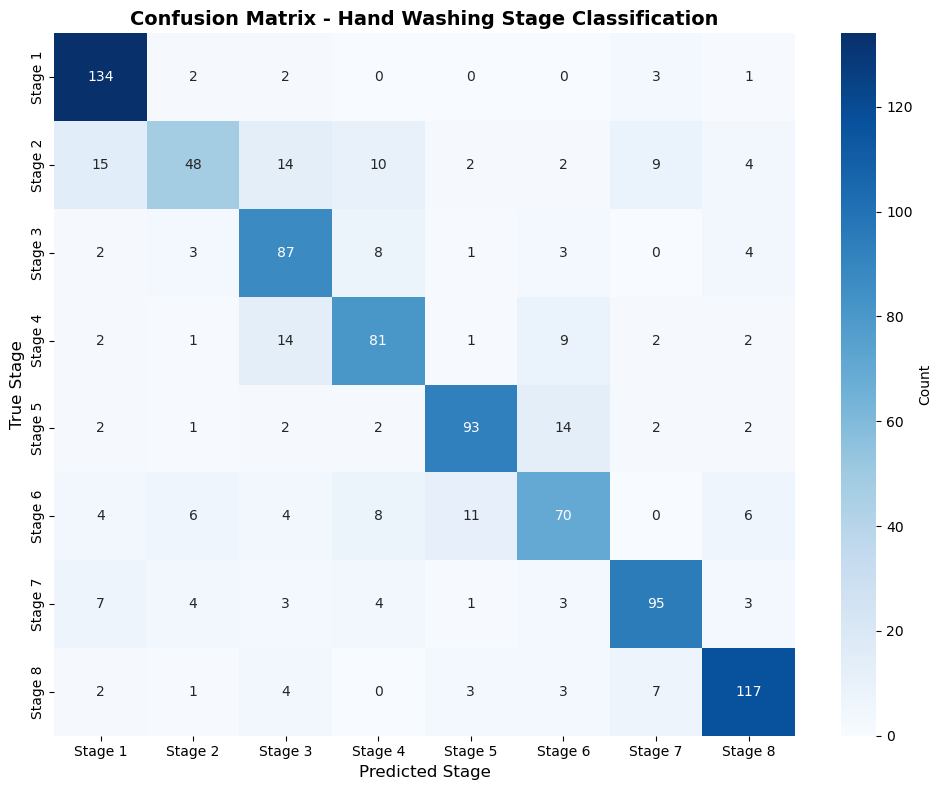


Confusion matrix plotted successfully!


In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("=" * 80)
print("PART 7: MODEL EVALUATION")
print("=" * 80)

print("\nMaking predictions on test set...")
y_pred_probs = model.predict(X_test, batch_size=batch_size)
y_pred = np.argmax(y_pred_probs, axis=1)

if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_test_labels = y_test

print("\n" + "=" * 80)
print("EVALUATION METRICS")
print("=" * 80)

# Accuracy
test_accuracy = accuracy_score(y_test_labels, y_pred)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Classification Report
print("\nClassification Report:")
print("=" * 80)
class_names = [f"Stage {i+1}" for i in range(8)]
print(classification_report(y_test_labels, y_pred, target_names=class_names, digits=4))

# Accuracy per Stage
print("\n" + "="*80)
print("Accuracy per Stage")
print("="*80)
for i, class_name in enumerate(class_names):
    idx = np.where(y_test_labels == i)[0]  # chỉ số các mẫu thuộc lớp i
    stage_acc = np.sum(y_pred[idx] == y_test_labels[idx]) / len(idx)
    print(f"{class_name}: {stage_acc:.4f} ({stage_acc*100:.2f}%)")

# 7.3) Confusion Matrix
print("\n" + "=" * 80)
print("Confusion Matrix")
print("=" * 80)

cm = confusion_matrix(y_test_labels, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Hand Washing Stage Classification', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Stage', fontsize=12)
plt.ylabel('True Stage', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion matrix plotted successfully!")

## Overall Performance
- **Test Accuracy:** **0.7632 (76.32%)** – a reasonably good result for an **8-class** classification task
- **Macro Avg (F1-score):** **0.7491** – indicates uneven performance across classes
- **Weighted Avg (F1-score):** **0.758** – reflects performance considering class distribution
- **Observation:** Macro F1 is lower than weighted F1 → difficult classes (especially Stage 2 and Stage 6) negatively affect overall performance

---

## Detailed Class-wise Evaluation
### Precision, Recall, F1-score 
| Stage | Precision | Recall | F1-score | Remarks |
|------|-----------|--------|----------|---------|
| Stage 1 | 0.7976 | **0.9437** | 0.8645 | Very high recall, most Stage 1 samples are correctly identified, slight over-prediction |
| Stage 2 | **0.7273** | **0.4615** | **0.5647** | Low recall, frequently misclassified as Stage 1, 3, and 4 |
| Stage 3 | 0.6692 | 0.8056 | 0.7311 | High recall but low precision, other stages are often predicted as Stage 3 |
| Stage 4 | 0.7168  |  0.7232  |  0.7200 | Good overall performance, mainly confused with Stage 3 and Stage 6 |
| Stage 5 | 0.8304  |  0.7881  |  0.8087 | Balanced precision and recall, stable recognition |
| Stage 6 | 0.6731  |  0.6422  |  **0.6573** | One of the most challenging stages to classify |
| Stage 7 | 0.8051  |  0.7917  |  0.7983 | Well recognized with minor confusion |
| Stage 8 | **0.8417** | 0.8540 | 0.8478 | Highest precision, Stage 8 is the easiest to identify |

### Accuracy
- High Accuracy: Stage 1 (94.37%), Stage 3 (80.56%), Stage 5 (78.81%), Stage 7 (79.17%), Stage 8 (85.40%) – these stages are recognized reliably.

- Low/Moderate Accuracy: Stage 2 (46.15%), Stage 6 (64.22%) – these stages show confusion and weaker performance.

---


## Confusion Matrix Observations

- **Stage 1:**  
  134 samples are correctly classified, with very limited confusion → strong class separability.

- **Stage 2:**  
  Only 48 correct predictions. Most misclassifications are into:  
  - Stage 1 (15 samples)  
  - Stage 3 (14 samples)  
  - Stage 4 (10 samples)  
  Confusion with Stage 7 (9 samples) exists but is less dominant than with Stages 1, 3, and 4.

- **Stage 3 and Stage 4:**  
  - **Stage 4 → Stage 3:** 14 samples (notable confusion)  
  - **Stage 3 → Stage 4:** 8 samples  
  This indicates *asymmetric confusion* rather than a strongly bidirectional one.  
  Additionally, Stage 3 is confused with **Stage 8 (4 samples)**.

- **Stage 6:**  
  Frequently misclassified as:  
  - Stage 5 (11 samples)  
  - Stage 4 (8 samples)  
  Additional confusion occurs with **Stage 2 (6 samples)** and **Stage 8 (6 samples)**, highlighting its overall ambiguity.

- **Stage 8:**  
  117 correctly classified samples → consistently stable and robust predictions.  

---

## Overall Conclusion
- **Overall Accuracy:** **76.32%** – acceptable but with room for improvement
- **Easiest-to-recognize stages:** 1, 8 (these stages have very distinct cues: Stage 1 involves running water, Stage 8 involves a towel for drying hands).
- **Easy-to-recognize stages:** 1, 3, 5, 7, 8
- **Difficult stages:** 2, 6
- **The confusion matrix reveals systematic misclassification patterns** → targeted improvements on difficult stages can significantly enhance model performance


### Training Curves

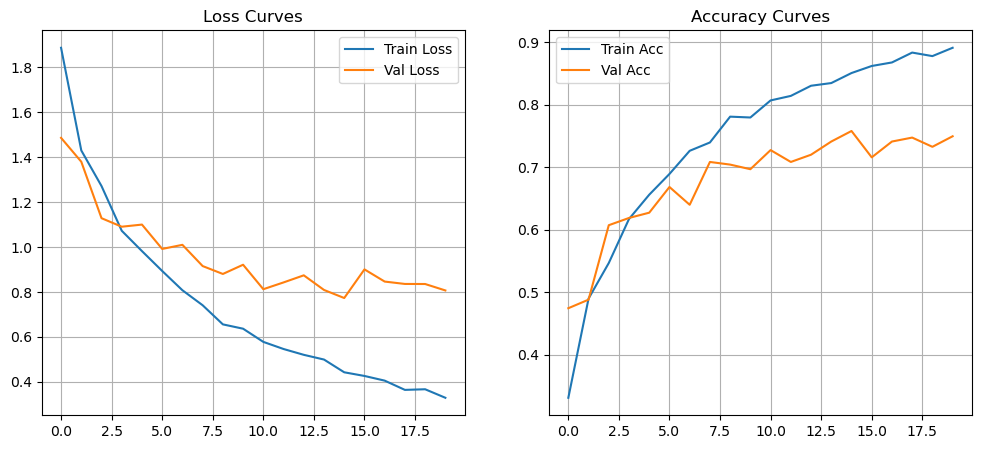

In [22]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history.get('accuracy', history.history.get('acc'))
val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()
plt.grid(True)
plt.show()

## Loss Curves (Left Plot)
- **Train Loss:** Continuously decreased from ~1.9 to ~0.33 after 20 epochs, indicating that the model is learning well on the training data.  
- **Validation Loss:** Dropped quickly in the first few epochs but started fluctuating and stabilized around ~0.8.  

**Observation:** There is a significant gap between train loss and validation loss, especially from epoch 5 onward → a sign of overfitting. The model is fitting the training data too closely and does not generalize well to the validation set.

## Accuracy Curves (Right Plot)
- **Train Accuracy:** Increased steadily, reaching ~0.89, consistent with the decreasing trend of train loss.  
- **Validation Accuracy:** Rose quickly initially but then fluctuated around ~0.74–0.76, showing little improvement despite continuous increase in train accuracy.  

**Observation:** Similar to the loss curves, the gap between train and validation accuracy reinforces the overfitting issue. The model has learned the training set features but has not generalized effectively to the validation set.

## Conclusion
- Despite applying data augmentation, early stopping, dropout, and batch normalization, the model still shows some signs of overfitting, but only for stages 2 and 6, as they have low F1 scores. The other labels do not appear to be overfitting, since their F1 scores are high.

### Make Inference
For some unseen data, make predictions using the trained model.


Inference on Random Test Images
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


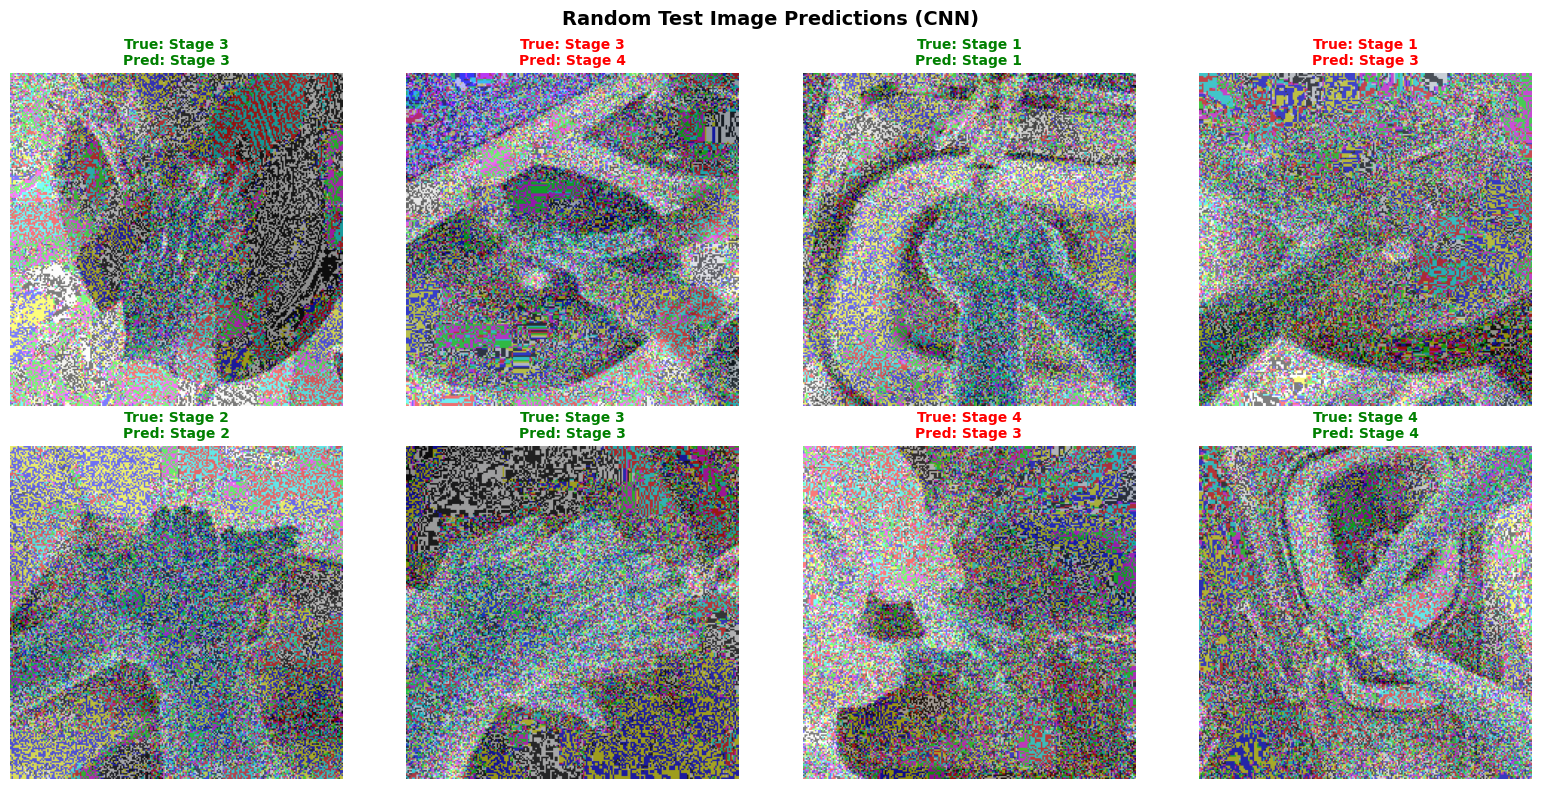


Prediction accuracy on 8 random samples: 5/8 (62.5%)

PART 7 COMPLETED: Model evaluation finished successfully!


In [23]:
print("\n" + "=" * 80)
print("Inference on Random Test Images")
print("=" * 80)

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
num_samples = 8  
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

sample_images = X_test[random_indices]
sample_true_labels = y_test[random_indices]

if sample_true_labels.ndim > 1 and sample_true_labels.shape[1] > 1:
    sample_true_labels = np.argmax(sample_true_labels, axis=1)

sample_pred_probs = model.predict(sample_images)
sample_pred_labels = np.argmax(sample_pred_probs, axis=1)

sample_images_display = ((sample_images + 1.0) * 127.5).astype(np.uint8)
sample_images_display = np.clip(sample_images_display, 0, 255)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx in range(num_samples):
    ax = axes[idx]
    img = sample_images_display[idx]
    true_label = sample_true_labels[idx]
    pred_label = sample_pred_labels[idx]

    ax.imshow(img)
    ax.axis('off')

    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: Stage {true_label + 1}\nPred: Stage {pred_label + 1}",
                 fontsize=10, fontweight='bold', color=color)

plt.suptitle('Random Test Image Predictions (CNN)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

correct = np.sum(sample_true_labels == sample_pred_labels)
print(f"\nPrediction accuracy on {num_samples} random samples: "
      f"{correct}/{num_samples} ({correct/num_samples*100:.1f}%)")

print("\n" + "=" * 80)
print("PART 7 COMPLETED: Model evaluation finished successfully!")
print("=" * 80)


It can be observed that images that are too blurry or where the fingers are not clear are often misclassified.

## 8. Model Explainability with SHAP

SHAP (SHapley Additive exPlanations) is a unified approach to explain the output of machine learning models. It helps us understand which features (pixels/regions) the model focuses on when making predictions.

### Why SHAP for this project?
- **Interpretability**: Understand which parts of hand washing images influence the model's decisions
- **Trust**: Build confidence in the model's predictions by visualizing what it "sees"
- **Debugging**: Identify if the model is focusing on relevant features
- **Healthcare Applications**: Critical for medical/health applications like COVID-19 prevention

In [ ]:
# Install SHAP library
!pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("SHAP version:", shap.__version__)
print("\nInitializing SHAP explainer for the MobileNetV3 model...")

In [ ]:
print("=" * 80)
print("PART 8: MODEL EXPLAINABILITY WITH SHAP")
print("=" * 80)

# Select a subset of test images for SHAP analysis
# SHAP can be computationally expensive, so we use a smaller sample
np.random.seed(42)
num_background_samples = 50  # Background data for DeepExplainer
num_explain_samples = 10     # Number of samples to explain

# Select random indices
background_indices = np.random.choice(len(X_train), num_background_samples, replace=False)
explain_indices = np.random.choice(len(X_test), num_explain_samples, replace=False)

# Get the samples
X_background = X_train[background_indices]
X_explain = X_test[explain_indices]

print(f"\nBackground dataset shape: {X_background.shape}")
print(f"Samples to explain shape: {X_explain.shape}")
print(f"\nNote: Using DeepExplainer for neural network interpretation")

In [ ]:
# Create SHAP DeepExplainer
# DeepExplainer is optimized for deep learning models like MobileNet
print("\nCreating SHAP DeepExplainer...")
print("This may take a few minutes...\n")

explainer = shap.DeepExplainer(model, X_background)

print("✓ SHAP explainer created successfully!")

In [ ]:
# Calculate SHAP values for the test samples
print("\nCalculating SHAP values...")
print("This process analyzes how each pixel contributes to the model's predictions...\n")

shap_values = explainer.shap_values(X_explain)

print(f"✓ SHAP values calculated!")
print(f"Shape of SHAP values: {np.array(shap_values).shape}")
print(f"\nInterpretation: SHAP values for {num_explain_samples} images across {num_classes} classes")

### SHAP Visualization

Below we visualize SHAP values to understand model decisions:

1. **Image Plot**: Shows which pixels contribute positively (red) or negatively (blue) to each class prediction
2. **Red pixels**: Increase the probability of the predicted class
3. **Blue pixels**: Decrease the probability of the predicted class
4. **Intensity**: Stronger colors indicate stronger influence on the prediction

In [ ]:
# Visualize SHAP values for the first few test images
print("\nVisualizing SHAP explanations...\n")

# Show SHAP values for first 5 images
num_display = min(5, num_explain_samples)

# Get predictions for these images
predictions = model.predict(X_explain[:num_display])
predicted_classes = np.argmax(predictions, axis=1)

print("Predicted classes for displayed images:", predicted_classes)
print("\nGenerating SHAP image plots...")

# Create SHAP image plot
# shap_values is a list of arrays, one per output class
# We'll show the SHAP values for the predicted class
shap.image_plot(shap_values, X_explain[:num_display], show=True)

In [ ]:
# Detailed explanation for a single prediction
print("\n" + "=" * 80)
print("Detailed SHAP Analysis for Individual Predictions")
print("=" * 80)

# Select one image for detailed analysis
sample_idx = 0
sample_image = X_explain[sample_idx:sample_idx+1]
sample_prediction = model.predict(sample_image)
predicted_class = np.argmax(sample_prediction[0])
confidence = sample_prediction[0][predicted_class]

print(f"\nAnalyzing image at index {sample_idx}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

# Show the original image
plt.figure(figsize=(6, 6))
# Denormalize image for display (assuming MobileNet preprocessing)
display_img = sample_image[0].copy()
# MobileNet preprocessing scales to [-1, 1], so we need to denormalize
display_img = (display_img + 1) / 2.0  # Scale to [0, 1]
display_img = np.clip(display_img, 0, 1)

plt.imshow(display_img)
plt.title(f"Original Image\nPredicted: Class {predicted_class} (Confidence: {confidence*100:.1f}%)")
plt.axis('off')
plt.tight_layout()
plt.show()

print("\nSHAP values indicate which regions of the image influenced this prediction.")

### Key Insights from SHAP Analysis

**What SHAP tells us about our hand washing classifier:**

1. **Feature Importance**: SHAP values reveal which parts of the image (hands, water, soap, gestures) are most important for classification

2. **Model Behavior**: By examining multiple predictions, we can verify the model focuses on relevant features (hand positions, washing technique) rather than background elements

3. **Trust & Transparency**: SHAP explanations help stakeholders understand and trust the AI system's decisions

4. **Debugging**: If SHAP shows the model focusing on irrelevant features, it indicates potential issues in training data or model architecture

**Application to COVID-19 Hand Washing:**
- Ensures the model correctly identifies proper hand washing techniques
- Validates that predictions are based on actual hand movements and not spurious correlations
- Provides interpretable feedback for educational purposes
- Critical for healthcare applications where model decisions need to be explainable

In [ ]:
# Print summary statistics
print("\n" + "=" * 80)
print("SHAP Analysis Summary")
print("=" * 80)

print(f"\n✓ Model: MobileNetV3Large with custom classification head")
print(f"✓ Number of classes: {num_classes}")
print(f"✓ SHAP explainer: DeepExplainer (optimized for deep learning)")
print(f"✓ Background samples: {num_background_samples}")
print(f"✓ Samples explained: {num_explain_samples}")
print(f"\n✓ SHAP implementation complete!")
print(f"\nThe model now has full explainability support for understanding predictions.")